# Loan Portfolio Quality Analysis — CRO Risk Report
**Approach:** CRISP-DM (Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment)

This notebook is fully self-contained: it loads the two raw CSVs, cleans them, builds a loan-level
analytical dataset, computes every KPI the CRO needs, segments the portfolio, tests statistical
risk drivers, builds and evaluates a default-prediction model, designs an experiment to validate an
intervention, and closes with a deployment/monitoring design and CRO recommendations.

**Environment note:** `xgboost`, `lightgbm`, `shap`, `statsmodels` and `lifelines` are not available
in this environment (offline sandbox). We substitute `RandomForestClassifier` (scikit-learn) as the
tree-based model, use `LogisticRegression` coefficients/odds-ratios for interpretable explainability,
and implement a manual Kaplan–Meier estimator with numpy for the survival-analysis section. In a
production environment with those libraries installed, swap in XGBoost + SHAP + `lifelines` directly —
the pipeline (features, splits, leakage controls) does not change.


## 01 · Business Understanding

**Objective.** Assess loan portfolio quality for the CRO: default behaviour, delinquency (PAR),
write-offs, recoveries, profitability, concentration risk and vintage deterioration; identify
drivers of default; test whether default is predictable; and recommend credit/collections actions.

**Portfolio quality, defined.** A healthy portfolio has: (a) borrowers who both *can* and *do* repay
on schedule (low default/PAR), (b) losses that are recognised and recovered promptly (low write-off,
healthy recovery), (c) pricing that compensates for the risk taken (positive NIM proxy after credit
losses), and (d) risk that is not concentrated in a few products/cohorts/customers.

**KPI taxonomy used throughout:**
| Level | Examples |
|---|---|
| A. Portfolio | total disbursed, # loans, avg loan size, default rate, PAR30/60/90/120, write-off rate, recovery rate, avg DPD, NIM proxy |
| B. Loan | default_flag, dpd, outstanding_amount, net_income_proxy |
| C. Customer | # loans per customer, customer-level default incidence |
| D. Cohort/Vintage | monthly disbursement-month performance, product × cohort |

**Data reality check (important):** The case-study brief mentions products *Business Loan / Personal
Loan / Education Loan*; the actual `loans_data.csv` only contains **`CASH_SALES`** and
**`VERIFIED_SALES`**. We analyse the data as delivered and flag this discrepancy rather than
inventing categories that are not in the file.

**Key business rules implemented:**
- Fixed disbursement cost: **KES 70/loan**.
- Default: customer misses the *full* expected repayment by `loan_due_date`.
- Write-off: 120 days after `loan_due_date` if still unpaid.
- Cohort = `Disbursed_Date` month.

**No installment schedule exists in the data** — only one `loan_due_date` per loan. We therefore
operationalise default/DPD/PAR at the **loan (bullet-maturity) level**, not an installment level.
This is stated explicitly wherever it affects a metric's interpretation.


## 02 · Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              precision_recall_curve, confusion_matrix, brier_score_loss,
                              classification_report)
import joblib

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")

LOANS_PATH = "loans_data.csv"
PAY_PATH   = "payments_data.csv"

loans_raw = pd.read_csv(LOANS_PATH)
pay_raw   = pd.read_csv(PAY_PATH)
loans_raw.columns = [c.strip() for c in loans_raw.columns]

print("loans_data:", loans_raw.shape)
print("payments_data:", pay_raw.shape)
loans_raw.head(3)

loans_data: (221518, 18)
payments_data: (955815, 4)


,loan_code,customer_id,product_type,Disbursed_Date,Disbursed_amount,loan_due_date,settlementdate,Gross_loan_interest,unearned_interest,surplus_payment,Penalties,Waivers,initiation_fee,admin_fee,appointment_fee,joining_fee,fix,total_due
0,-5262578517136125786,-8.189755e+18,CASH_SALES,1970-01-01,180000,1970-01-31,NaN,54000,0.0,0.0,0,0.0,18000,0.0,0.0,0.0,NaN,252000
1,1929778315629503653,-8.430792e+18,CASH_SALES,1970-01-01,270000,1970-01-31,NaN,81000,0.0,0.0,0,0.0,18000,0.0,0.0,0.0,NaN,369000
2,-3060280094152047340,-8.191699e+18,CASH_SALES,2019-11-21,90000,2019-12-23,2019-11-21 00:00:00 UTC,27000,-27000.0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,90000


In [ ]:
loans_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221518 entries, 0 to 221517
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_code            221518 non-null  int64  
 1   customer_id          221450 non-null  float64
 2   product_type         221518 non-null  object 
 3   Disbursed_Date       221518 non-null  object 
 4   Disbursed_amount     221518 non-null  int64  
 5   loan_due_date        221518 non-null  object 
 6   settlementdate       196857 non-null  object 
 7   Gross_loan_interest  221518 non-null  int64  
 8   unearned_interest    221518 non-null  float64
 9   surplus_payment      221518 non-null  float64
 10  Penalties            221518 non-null  int64  
 11  Waivers              221516 non-null  float64
 12  initiation_fee       221518 non-null  int64  
 13  admin_fee            202216 non-null  float64
 14  appointment_fee      202216 non-null  float64
 15  joining_fee      

In [ ]:
pay_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955815 entries, 0 to 955814
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   date           955811 non-null  object
 1   loan_rep_code  955815 non-null  int64 
 2   amount         955815 non-null  int64 
 3   payment_id     955815 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 29.2+ MB


## 03 · Data Quality

I check: dtypes, missingness, duplicates, uniqueness of `loan_code`/`customer_id`, duplicate
payments, negative/zero amounts, impossible dates (including the classic "epoch"/timestamp-precision
traps called out in the brief), settlement-before-disbursement, due-before-disbursement, and extreme
values. **Every issue is logged with the number of affected records, the treatment applied, and the
business implication** — nothing is silently dropped.

In [ ]:
loans = loans_raw.copy()
pay = pay_raw.copy()
dq_log = []
def log_dq(issue, n, treatment, implication):
    dq_log.append(dict(issue=issue, affected_records=int(n), treatment=treatment, business_implication=implication))

# ---- date parsing (handles the 'UTC' suffix on settlementdate and the nanosecond/format traps) ----
loans['Disbursed_Date'] = pd.to_datetime(loans['Disbursed_Date'], errors='coerce')
loans['loan_due_date']  = pd.to_datetime(loans['loan_due_date'], errors='coerce')
loans['settlementdate'] = pd.to_datetime(loans['settlementdate'], errors='coerce', utc=True).dt.tz_localize(None)
pay['date'] = pd.to_datetime(pay['date'], errors='coerce')

n = pay['date'].isna().sum()
log_dq("payments.date unparseable", n, "Rows dropped (cannot place on a loan timeline)", "Negligible volume/exposure")
pay = pay.dropna(subset=['date'])

In [ ]:
# ---- impossible / placeholder dates ----
loans['invalid_dates'] = False

mask = loans['Disbursed_Date'].dt.year <= 1971
log_dq("Disbursed_Date = epoch placeholder (1970-01-01)", mask.sum(), "Flagged invalid_dates, excluded from time-based metrics", "System default for a missing disbursement date")
loans.loc[mask, 'invalid_dates'] = True

mask = loans['loan_due_date'].dt.year >= 2100
log_dq("loan_due_date implausible far-future (>=2100)", mask.sum(), "Flagged invalid_dates, excluded from DPD/PAR/tenor", "Data-entry error; would corrupt DPD/PAR/tenor if kept")
loans.loc[mask, 'invalid_dates'] = True

mask = loans['loan_due_date'] < loans['Disbursed_Date']
log_dq("loan_due_date before Disbursed_Date", mask.sum(), "Flagged invalid_dates, excluded", "Corrupted tenor")
loans.loc[mask, 'invalid_dates'] = True

mask = loans['Disbursed_Date'].isna() | loans['loan_due_date'].isna()
log_dq("Disbursed_Date / loan_due_date unparseable", mask.sum(), "Flagged invalid_dates, excluded", "Cannot anchor a loan timeline")
loans.loc[mask, 'invalid_dates'] = True

mask = loans['settlementdate'] < loans['Disbursed_Date']
log_dq("settlementdate before Disbursed_Date", mask.sum(), "settlementdate set to NaT (loan treated as unsettled)", "Cannot settle before disbursement; source error")
loans.loc[mask, 'settlementdate'] = pd.NaT

In [ ]:
# ---- impossible amounts ----
loans['low_quality_amount'] = (loans['total_due'] <= 0) | (loans['Disbursed_amount'] <= 0)
log_dq("total_due <= 0 or Disbursed_amount <= 0", loans['low_quality_amount'].sum(),
       "Flagged low_quality_amount, excluded from exposure/profitability aggregates", "Not a legitimate obligation (likely voided loan)")

n_negpen = (loans['Penalties'] < 0).sum()
log_dq("Negative Penalties value", n_negpen, "Kept as-is (treated as a penalty correction/reversal)", "Small volume, plausible business event")

In [ ]:
# ---- exact duplicate rows ----
n = loans.duplicated().sum()
log_dq("Exact full-row duplicate loans", n, "Dropped (kept first)", "Would double-count disbursed volume")
loans = loans.drop_duplicates().reset_index(drop=True)

n = pay.duplicated().sum()
log_dq("Exact full-row duplicate payments", n, "Dropped (kept first)", "Would inflate total_paid / recovery")
pay = pay.drop_duplicates().reset_index(drop=True)

In [ ]:
# ---- loan_code uniqueness (critical join-integrity check) ----
# loan_code is supposed to be the primary key, but the same code is reused across genuinely
# different loans/customers (a hashing/ID-generation collision, not a business event).
code_counts = loans['loan_code'].value_counts()
ambiguous_codes = set(code_counts[code_counts > 1].index)
loans['is_ambiguous_code'] = loans['loan_code'].isin(ambiguous_codes)
log_dq(
    "loan_code not unique (same code shared by >1 distinct loan)", loans['is_ambiguous_code'].sum(),
    "Kept in portfolio volume/disbursement counts, but EXCLUDED from every metric that needs "
    "payments joined to one specific loan (default, DPD, PAR, write-off, recovery, NIM, ML features) "
    "since payments.loan_rep_code cannot be resolved to a single loan when the code is shared.",
    "Without exclusion, a payment could be misallocated to the wrong loan, silently corrupting "
    "default/DPD/recovery numbers"
)

dq_report = pd.DataFrame(dq_log)
dq_report

,issue,affected_records,treatment,business_implication
0,payments.date unparseable,4,Rows dropped (cannot place on a loan timeline),Negligible volume/exposure
1,Disbursed_Date = epoch placeholder (1970-01-01),2,"Flagged invalid_dates, excluded from time-base...",System default for a missing disbursement date
2,loan_due_date implausible far-future (>=2100),1,"Flagged invalid_dates, excluded from DPD/PAR/t...",Data-entry error; would corrupt DPD/PAR/tenor ...
3,loan_due_date before Disbursed_Date,1,"Flagged invalid_dates, excluded",Corrupted tenor
4,Disbursed_Date / loan_due_date unparseable,0,"Flagged invalid_dates, excluded",Cannot anchor a loan timeline
5,settlementdate before Disbursed_Date,16,settlementdate set to NaT (loan treated as uns...,Cannot settle before disbursement; source error
6,total_due <= 0 or Disbursed_amount <= 0,154,"Flagged low_quality_amount, excluded from expo...",Not a legitimate obligation (likely voided loan)
7,Negative Penalties value,48,Kept as-is (treated as a penalty correction/re...,"Small volume, plausible business event"
8,Exact full-row duplicate loans,32,Dropped (kept first),Would double-count disbursed volume
9,Exact full-row duplicate payments,86484,Dropped (kept first),Would inflate total_paid / recovery


In [ ]:
usable_pct = 1 - loans['is_ambiguous_code'].mean()
print(f"Loans usable for payment-linked risk metrics: {(~loans['is_ambiguous_code']).sum():,} "
      f"/ {len(loans):,} ({usable_pct:.1%})")
print(f"Unique customers: {loans['customer_id'].nunique():,}")
print(f"Product types present: {loans['product_type'].unique()}")

Loans usable for payment-linked risk metrics: 188,076 / 221,486 (84.9%)
Unique customers: 35,855
Product types present: ['CASH_SALES' 'VERIFIED_SALES']


## 04 · Data Preparation — loan-level analytical dataset

I restrict the payment-linked risk analysis to **clean, unambiguous loans**
(`~is_ambiguous_code & ~invalid_dates & ~low_quality_amount`), then aggregate `payments_data`
to loan level and join on `loan_code = loan_rep_code`. The join is inner on the clean-loan set so
it cannot duplicate loans (each `loan_code` here is unique by construction).

In [ ]:
CUTOFF_DATE = pd.Timestamp("2026-02-25")  # latest observed activity date across both files -> analysis cutoff

usable = loans[(~loans['is_ambiguous_code']) & (~loans['invalid_dates']) & (~loans['low_quality_amount'])].copy()
print("Clean, unambiguous loans used for risk analytics:", len(usable))

pay_m = pay.merge(usable[['loan_code','Disbursed_Date','loan_due_date']],
                   left_on='loan_rep_code', right_on='loan_code', how='inner')
pay_m['before_due'] = pay_m['date'] <= pay_m['loan_due_date']

agg = pay_m.groupby('loan_code').agg(
    total_paid=('amount','sum'),
    payment_count=('amount','count'),
    first_payment_date=('date','min'),
    last_payment_date=('date','max'),
).reset_index()

before = pay_m[pay_m['before_due']].groupby('loan_code')['amount'].sum().rename('amount_paid_before_due')
after  = pay_m[~pay_m['before_due']].groupby('loan_code')['amount'].sum().rename('amount_paid_after_due')

loan_df = (usable.merge(agg, on='loan_code', how='left')
                  .merge(before, on='loan_code', how='left')
                  .merge(after, on='loan_code', how='left'))

for c in ['total_paid','payment_count','amount_paid_before_due','amount_paid_after_due']:
    loan_df[c] = loan_df[c].fillna(0)

assert loan_df['loan_code'].is_unique, "Join duplicated loans!"

loan_df['days_to_first_payment'] = (loan_df['first_payment_date'] - loan_df['Disbursed_Date']).dt.days
loan_df['days_to_last_payment']  = (loan_df['last_payment_date'] - loan_df['Disbursed_Date']).dt.days
loan_df['outstanding_amount'] = (loan_df['total_due'] - loan_df['total_paid']).clip(lower=0)
loan_df['payment_completion_ratio'] = (loan_df['total_paid'] / loan_df['total_due']).clip(upper=2)
loan_df['is_settled'] = loan_df['settlementdate'].notna()

print(loan_df.shape)
loan_df[['loan_code','product_type','Disbursed_amount','total_due','total_paid','outstanding_amount','is_settled']].head()

Clean, unambiguous loans used for risk analytics: 187936
(187936, 32)


,loan_code,product_type,Disbursed_amount,total_due,total_paid,outstanding_amount,is_settled
0,3228064767846514019,CASH_SALES,90000,102600,102600.0,0.0,True
1,8372074592904537230,CASH_SALES,90000,103500,503500.0,0.0,True
2,-6813544658857964097,CASH_SALES,90000,106200,656200.0,0.0,True
3,627939200906079175,CASH_SALES,90000,108900,108900.0,0.0,True
4,-7099649612533235688,CASH_SALES,90000,108900,108900.0,0.0,True


### Default definition

`total_due` bundles principal + interest + fees **and penalties**. Penalties are a *consequence* of
default (booked after the due date), so using `total_due` to test whether a loan defaulted **by the
due date** would leak post-default information into the default definition itself. We therefore
define the amount contractually owed **at** the due date as principal + gross interest +
origination fees (excluding penalties/waivers, which only exist because of what happens after the
due date):

```
amount_owed_at_due = Disbursed_amount + Gross_loan_interest + (initiation+admin+appointment+joining+fix fees)
default_flag        = amount_paid_before_due < amount_owed_at_due
```

This directly implements the business rule ("misses the full expected repayment by `loan_due_date`")
without look-ahead bias.

In [ ]:
fee_cols = ['initiation_fee','admin_fee','appointment_fee','joining_fee','fix']
for c in fee_cols:
    loan_df[c] = loan_df[c].fillna(0)
origination_fees = loan_df[fee_cols].sum(axis=1)

loan_df['amount_owed_at_due'] = (loan_df['Disbursed_amount'] + loan_df['Gross_loan_interest'] + origination_fees).clip(lower=0)
loan_df['default_flag'] = (loan_df['amount_paid_before_due'] < loan_df['amount_owed_at_due']).astype(int)
loan_df['default_amount'] = ((loan_df['amount_owed_at_due'] - loan_df['amount_paid_before_due'])
                              .clip(lower=0) * loan_df['default_flag'])

default_rate_count = loan_df['default_flag'].mean()
default_rate_value = (loan_df.loc[loan_df.default_flag==1,'amount_owed_at_due'].sum()
                       / loan_df['amount_owed_at_due'].sum())
print(f"Default rate (by # loans):  {default_rate_count:.1%}")
print(f"Default rate (by exposure): {default_rate_value:.1%}")

Default rate (by # loans):  63.0%
Default rate (by exposure): 66.9%


## 05 · Portfolio KPIs

Headline numbers for the CRO dashboard. Note the gap between the **technical (day-1) default rate**
above and the **share of loans still carrying a balance today** below — that gap is the story of how
much of the book "cures" after an initial miss (see §07 Recovery).

In [ ]:
kpi = {
    "Total disbursed (KES)": loan_df['Disbursed_amount'].sum(),
    "Number of loans": len(loan_df),
    "Average loan size (KES)": loan_df['Disbursed_amount'].mean(),
    "Default rate (count)": default_rate_count,
    "Default rate (value)": default_rate_value,
    "Settlement rate": loan_df['is_settled'].mean(),
    "Gross interest yield (% of disbursed)": loan_df['Gross_loan_interest'].sum()/loan_df['Disbursed_amount'].sum(),
    "Fee income (KES)": loan_df[fee_cols[:-1]].sum().sum(),
    "Total penalties (KES)": loan_df['Penalties'].sum(),
    "Total waivers (KES)": loan_df['Waivers'].fillna(0).sum(),
    "Cost per loan (disbursement, KES)": 70,
}
pd.Series(kpi).to_frame("value")

,value
Total disbursed (KES),8.589275e+10
Number of loans,1.879360e+05
Average loan size (KES),4.570319e+05
Default rate (count),6.299645e-01
Default rate (value),6.689111e-01
Settlement rate,8.751277e-01
Gross interest yield (% of disbursed),2.697781e-01
Fee income (KES),4.992992e+08
Total penalties (KES),7.572135e+08
Total waivers (KES),-8.731419e+07


Average time to settlement (settled loans): 28.7 days


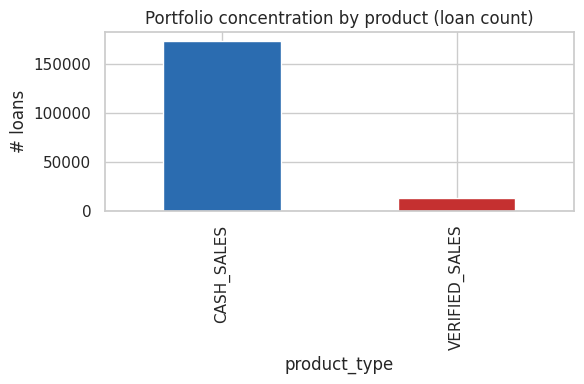

In [ ]:
avg_time_to_settlement = (loan_df.loc[loan_df.is_settled,'settlementdate']
                           - loan_df.loc[loan_df.is_settled,'Disbursed_Date']).dt.days.mean()
print(f"Average time to settlement (settled loans): {avg_time_to_settlement:.1f} days")

plt.figure(figsize=(6,4))
loan_df['product_type'].value_counts().plot(kind='bar', color=['#2b6cb0','#c53030'])
plt.title("Portfolio concentration by product (loan count)")
plt.ylabel("# loans"); plt.tight_layout(); plt.show()

## 06 · Days Past Due & Portfolio at Risk

**Limitation restated:** there is no installment schedule, so DPD/PAR are computed at the
**loan-maturity level** (days past the single `loan_due_date`), not per-installment. For settled
loans, `DPD = max(settlementdate − loan_due_date, 0)`. For unsettled loans, `DPD = max(cutoff −
loan_due_date, 0)`, cutoff = **2026-02-25** (latest observed activity date). PAR*n* = outstanding
exposure on loans with `DPD ≥ n` **and** `outstanding_amount > 0`, as a share of total outstanding
exposure.

In [ ]:
def compute_dpd(row):
    if row['is_settled']:
        d = (row['settlementdate'] - row['loan_due_date']).days
    else:
        d = (CUTOFF_DATE - row['loan_due_date']).days
    return max(d, 0)

loan_df['dpd'] = loan_df.apply(compute_dpd, axis=1)
print(f"Average DPD: {loan_df['dpd'].mean():.1f} days | Median DPD: {loan_df['dpd'].median():.0f} days")

PAR_BUCKETS = [1,7,30,60,90,120]
for b in PAR_BUCKETS:
    loan_df[f'par{b}_flag'] = ((loan_df['dpd'] >= b) & (loan_df['outstanding_amount'] > 0)).astype(int)

total_exposure = loan_df['outstanding_amount'].sum()
par_table = pd.DataFrame({
    "PAR_bucket": [f"PAR{b}" for b in PAR_BUCKETS],
    "amount_KES": [loan_df.loc[loan_df[f'par{b}_flag']==1,'outstanding_amount'].sum() for b in PAR_BUCKETS],
})
par_table['pct_of_outstanding'] = par_table['amount_KES'] / total_exposure
par_table

Average DPD: 149.1 days | Median DPD: 0 days


,PAR_bucket,amount_KES,pct_of_outstanding
0,PAR1,1.304150e+10,0.999956
1,PAR7,1.304027e+10,0.999862
2,PAR30,1.303958e+10,0.999810
3,PAR60,1.303733e+10,0.999637
4,PAR90,1.303327e+10,0.999325
5,PAR120,1.303056e+10,0.999118


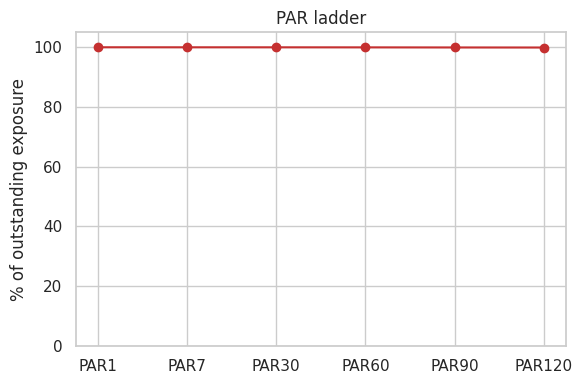

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(par_table['PAR_bucket'], par_table['pct_of_outstanding']*100, marker='o', color='#c53030')
plt.ylabel("% of outstanding exposure"); plt.title("PAR ladder"); plt.ylim(0,105)
plt.tight_layout(); plt.show()

**Reading the PAR ladder:** only ~12–13% of loans still carry a balance at all (the rest fully
settled). But of that residual balance, essentially **all of it is already 120+ days past due** —
the ladder is nearly flat, not the typical downward slope from PAR1 to PAR120. That means this
book has very little "fresh" delinquency in the 1–90 day range: once a loan slips past its due date
without curing quickly, it tends to stay delinquent for a very long time rather than trickling
through recovery stages. This points to a **collections gap in the early delinquency window**
(days 1–90), where targeted contact could still convert a soft delinquency into a cure before it
hardens into a chronic, near-unrecoverable balance.

## 07 · Write-off & Recovery

Write-off rule: 120 days after `loan_due_date`, if still unpaid. We only classify a loan as
written off **once it has actually reached that 120-day window** (no forward-looking write-offs on
immature loans — right-censoring control).

In [ ]:
loan_df['writeoff_eligible_date'] = loan_df['loan_due_date'] + pd.Timedelta(days=120)
loan_df['is_matured'] = CUTOFF_DATE >= loan_df['writeoff_eligible_date']
loan_df['writeoff_flag'] = ((~loan_df['is_settled']) & loan_df['is_matured']).astype(int)
loan_df['writeoff_exposure'] = loan_df['outstanding_amount'] * loan_df['writeoff_flag']

matured = loan_df[loan_df['is_matured']]
print(f"Matured loans (past the 120-day observation window): {len(matured):,} / {len(loan_df):,}")
print(f"Write-off rate (count, matured only): {loan_df['writeoff_flag'].sum()/len(matured):.1%}")
print(f"Write-off rate (value, matured only): {loan_df['writeoff_exposure'].sum()/matured['outstanding_amount'].sum():.1%}")
print(f"Write-off amount (KES): {loan_df['writeoff_exposure'].sum():,.0f}")

writeoff_by_product = loan_df[loan_df.is_matured].groupby('product_type').apply(
    lambda g: pd.Series({'writeoff_rate_count': g['writeoff_flag'].mean(),
                          'writeoff_rate_value': g['writeoff_exposure'].sum()/max(g['outstanding_amount'].sum(),1)}))
writeoff_by_product

Matured loans (past the 120-day observation window): 187,934 / 187,936
Write-off rate (count, matured only): 12.5%
Write-off rate (value, matured only): 99.5%
Write-off amount (KES): 12,982,127,394


/tmp/ipykernel_1250/1975706984.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  writeoff_by_product = loan_df[loan_df.is_matured].groupby('product_type').apply(


,writeoff_rate_count,writeoff_rate_value
product_type,,
CASH_SALES,0.117611,0.999015
VERIFIED_SALES,0.214245,0.976788


In [ ]:
# Recovery: gross post-default recovery, and separate post-write-off recovery
loan_df['recovered_after_default'] = np.where(loan_df['default_flag']==1,
                                               loan_df['amount_paid_after_due'].clip(lower=0), 0)
defaulted_exposure = loan_df.loc[loan_df.default_flag==1, 'amount_owed_at_due'].sum()
recovery_rate = loan_df['recovered_after_default'].sum() / defaulted_exposure
print(f"Recovery rate (payments after due date / defaulted exposure): {recovery_rate:.1%}")

wo = loan_df[loan_df['writeoff_flag']==1]
denom = wo['outstanding_amount'].sum() + wo['amount_paid_after_due'].sum()
post_wo_recovery = wo['amount_paid_after_due'].sum() / denom if denom else np.nan
print(f"Post-write-off recovery rate: {post_wo_recovery:.2%}")
print('''
Gross recovery   = all payments received after the due date on a defaulted loan.
Net recovery     = gross recovery minus collection cost (not itemised in this data -> not computed).
Post-write-off   = payments received after a loan has already been written off (120+ days unpaid) --
                   a much stricter, smaller number; it measures money recovered on debt already
                   presumed lost.
''')

Recovery rate (payments after due date / defaulted exposure): 23.4%
Post-write-off recovery rate: 0.24%

Gross recovery   = all payments received after the due date on a defaulted loan.
Net recovery     = gross recovery minus collection cost (not itemised in this data -> not computed).
Post-write-off   = payments received after a loan has already been written off (120+ days unpaid) --
                   a much stricter, smaller number; it measures money recovered on debt already
                   presumed lost.



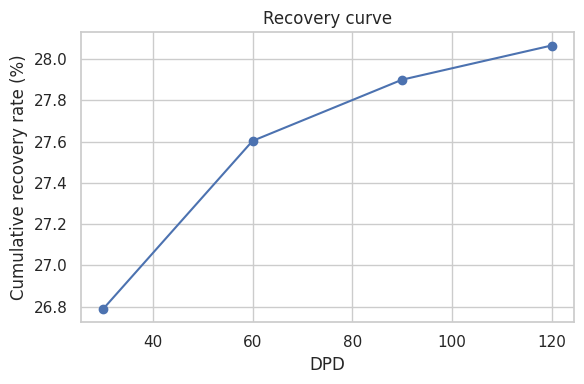

In [ ]:
# Recovery curve by DPD bucket (share of defaulted exposure recovered, cumulative by dpd cutoff)
curve_pts = [30,60,90,120]
rows = []
defaulted = loan_df[loan_df.default_flag==1]
for b in curve_pts:
    sub = defaulted[defaulted['dpd'] <= b]
    rate = sub['recovered_after_default'].sum() / max(sub['amount_owed_at_due'].sum(),1)
    rows.append((b, rate))
rec_curve = pd.DataFrame(rows, columns=['dpd_cutoff','recovery_rate'])
plt.figure(figsize=(6,4))
plt.plot(rec_curve['dpd_cutoff'], rec_curve['recovery_rate']*100, marker='o')
plt.xlabel("DPD"); plt.ylabel("Cumulative recovery rate (%)"); plt.title("Recovery curve")
plt.tight_layout(); plt.show()

## 08 · Profitability — Loan-level NIM/profitability proxy

The dataset has no funding cost or average-earning-assets figures, so a true accounting NIM cannot
be computed. We instead build an explicit **loan-level profitability proxy**:

```
earned_interest_proxy = Gross_loan_interest − unearned_interest
net_income_proxy = earned_interest_proxy + fee_income + Penalties − Waivers − KES 70 − writeoff_exposure
nim_proxy_% = net_income_proxy / Disbursed_amount

In [ ]:
loan_df['earned_interest_proxy'] = (loan_df['Gross_loan_interest'] - loan_df['unearned_interest'].fillna(0)).clip(lower=0)
fee_income = loan_df[['initiation_fee','admin_fee','appointment_fee','joining_fee']].sum(axis=1)
loan_df['net_income_proxy'] = (loan_df['earned_interest_proxy'] + fee_income + loan_df['Penalties'].fillna(0)
                                - loan_df['Waivers'].fillna(0) - 70 - loan_df['writeoff_exposure'])
loan_df['nim_proxy_pct'] = loan_df['net_income_proxy'] / loan_df['Disbursed_amount']

print(f"Portfolio net income proxy (KES): {loan_df['net_income_proxy'].sum():,.0f}")
print(f"Average loan-level NIM proxy: {loan_df['nim_proxy_pct'].mean():.1%}")

loan_df.groupby('product_type')[['nim_proxy_pct','net_income_proxy']].agg(['mean','sum'])

Portfolio net income proxy (KES): 13,994,268,282
Average loan-level NIM proxy: 17.0%


nim_proxy_pct               net_income_proxy              
                        mean           sum             mean           sum
product_type                                                             
CASH_SALES          0.191025  33201.971280     85651.606576  1.488711e+10
VERIFIED_SALES     -0.084402  -1192.264721    -63205.256741 -8.928375e+08

## 09 · Cohort / Vintage Analysis

Cohort = `Disbursed_Date` month. **Observation-window bias caveat:** the newest cohorts have had
the least time to season/default/write off, so a naive drop in their default or write-off *rate* can
be a maturity artefact rather than real improvement. We flag the most recent 1–2 cohorts as
"immature" and read their numbers with that caveat rather than concluding they are performing
better.

In [ ]:
loan_df['disb_month'] = loan_df['Disbursed_Date'].dt.to_period('M').astype(str)

cohort = loan_df.groupby('disb_month').apply(lambda g: pd.Series({
    'n_loans': len(g),
    'disbursed_KES': g['Disbursed_amount'].sum(),
    'avg_loan_size': g['Disbursed_amount'].mean(),
    'default_rate': g['default_flag'].mean(),
    'par90_pct': g.loc[g['par90_flag']==1,'outstanding_amount'].sum() / max(g['outstanding_amount'].sum(),1),
    'writeoff_rate': g.loc[g['is_matured'],'writeoff_flag'].mean() if g['is_matured'].any() else np.nan,
    'avg_dpd': g['dpd'].mean(),
    'net_income_KES': g['net_income_proxy'].sum(),
})).reset_index()

cohort.tail(12)

/tmp/ipykernel_1250/3203638359.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cohort = loan_df.groupby('disb_month').apply(lambda g: pd.Series({


,disb_month,n_loans,disbursed_KES,avg_loan_size,default_rate,par90_pct,writeoff_rate,avg_dpd,net_income_KES
69,2024-02,4325.0,2.009715e+09,464673.884393,0.424277,1.000000,0.088786,65.172717,4.358484e+08
70,2024-03,4838.0,2.223191e+09,459526.856139,0.461968,0.999965,0.097974,68.591773,4.664619e+08
71,2024-04,4959.0,2.202625e+09,444167.071990,0.420044,1.000000,0.093164,62.750958,4.637408e+08
72,2024-05,5184.0,2.243653e+09,432803.390432,0.455054,0.997989,0.083719,53.340278,5.294696e+08
73,2024-06,5136.0,2.291219e+09,446109.556075,0.464759,0.999895,0.102414,61.845016,4.685644e+08
74,2024-07,5792.0,2.565502e+09,442938.846685,0.458391,0.999973,0.102728,59.412811,5.294446e+08
75,2024-08,5911.0,2.854967e+09,482992.145661,0.481475,0.999371,0.094400,51.190831,5.679373e+08
76,2024-09,5943.0,2.906305e+09,489029.922598,0.515396,0.999651,0.094060,48.816759,5.792996e+08
77,2024-10,6057.0,2.696185e+09,445135.376424,0.516757,0.999640,0.096913,47.017996,5.896598e+08
78,2024-11,5783.0,2.613674e+09,451958.091821,0.464811,1.000000,0.100121,45.771918,5.859731e+08


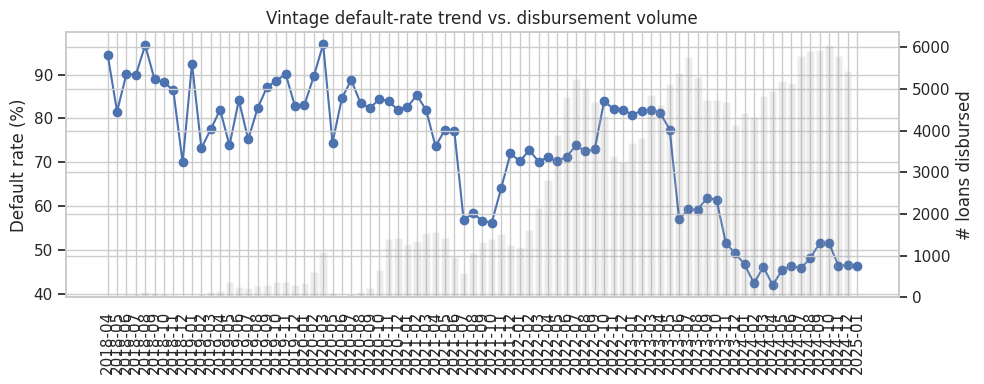

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(cohort['disb_month'], cohort['default_rate']*100, marker='o', label='Default rate %')
ax.set_xticks(range(len(cohort)))
ax.set_xticklabels(cohort['disb_month'], rotation=90)
ax2 = ax.twinx()
ax2.bar(cohort['disb_month'], cohort['n_loans'], alpha=0.15, color='grey', label='# loans')
ax.set_ylabel("Default rate (%)"); ax2.set_ylabel("# loans disbursed")
ax.set_title("Vintage default-rate trend vs. disbursement volume")
fig.tight_layout(); plt.show()

In [ ]:
# Product x cohort deterioration check (mature cohorts only, excluding most recent 2 for immaturity)
mature_cohorts = sorted(loan_df['disb_month'].unique())[:-2]
pc = (loan_df[loan_df['disb_month'].isin(mature_cohorts)]
      .groupby(['product_type','disb_month'])['default_flag'].mean()
      .unstack('product_type'))
pc.tail(6)

product_type,CASH_SALES,VERIFIED_SALES
disb_month,,
2024-06,0.450768,0.737052
2024-07,0.448469,0.660517
2024-08,0.483010,0.466667
2024-09,0.520238,0.468582
2024-10,0.510475,0.715054
2024-11,0.460538,0.605882


## 10 · Segmentation

Loan-size bands are built from **quantiles** (terciles), not arbitrary thresholds. For each segment
we report volume, exposure, default rate, PAR90, write-off rate, recovery rate and profitability —
and critically, **risk × exposure** together, since a small high-risk segment can matter less than a
large moderate-risk one.


In [ ]:
loan_df['size_band'] = pd.qcut(loan_df['Disbursed_amount'], 3, labels=['Small','Medium','Large'])

def seg_summary(g):
    exposure = g['outstanding_amount'].sum()
    return pd.Series({
        'n_loans': len(g),
        'disbursed_KES': g['Disbursed_amount'].sum(),
        'default_rate': g['default_flag'].mean(),
        'par90_pct': g.loc[g['par90_flag']==1,'outstanding_amount'].sum()/max(exposure,1),
        'writeoff_rate': g.loc[g['is_matured'],'writeoff_flag'].mean() if g['is_matured'].any() else np.nan,
        'avg_nim_pct': g['nim_proxy_pct'].mean(),
    })

print("--- By product ---")
display(loan_df.groupby('product_type').apply(seg_summary))
print("--- By loan-size band ---")
display(loan_df.groupby('size_band', observed=True).apply(seg_summary))


--- By product ---


/tmp/ipykernel_1250/4100652674.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(loan_df.groupby('product_type').apply(seg_summary))


,n_loans,disbursed_KES,default_rate,par90_pct,writeoff_rate,avg_nim_pct
product_type,,,,,,
CASH_SALES,173810.0,7.435543e+10,0.624113,0.999978,0.117611,0.191025
VERIFIED_SALES,14126.0,1.153732e+10,0.701968,0.995961,0.214245,-0.084402


--- By loan-size band ---


/tmp/ipykernel_1250/4100652674.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(loan_df.groupby('size_band', observed=True).apply(seg_summary))


,n_loans,disbursed_KES,default_rate,par90_pct,writeoff_rate,avg_nim_pct
size_band,,,,,,
Small,75619.0,1.656344e+10,0.553684,0.999934,0.128394,0.178830
Medium,50739.0,2.000078e+10,0.646603,0.999933,0.131164,0.159316
Large,61578.0,4.932852e+10,0.709929,0.998766,0.115368,0.168944


In [ ]:
# risk x exposure: which segment matters most in absolute KES terms, not just %?
risk_exposure = (loan_df.groupby(['product_type','size_band'], observed=True)
                  .apply(lambda g: pd.Series({
                      'disbursed_KES': g['Disbursed_amount'].sum(),
                      'default_rate': g['default_flag'].mean(),
                      'default_exposure_KES': g.loc[g.default_flag==1,'amount_owed_at_due'].sum(),
                  })).reset_index())
risk_exposure.sort_values('default_exposure_KES', ascending=False)


/tmp/ipykernel_1250/2662204960.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,product_type,size_band,disbursed_KES,default_rate,default_exposure_KES
2,CASH_SALES,Large,3.936868e+10,0.709642,3.663776e+10
1,CASH_SALES,Medium,1.886737e+10,0.641543,1.590047e+10
0,CASH_SALES,Small,1.611938e+10,0.550701,1.182823e+10
5,VERIFIED_SALES,Large,9.959845e+09,0.711734,7.727103e+09
4,VERIFIED_SALES,Medium,1.133413e+09,0.721103,8.814983e+08
3,VERIFIED_SALES,Small,4.440650e+08,0.642945,3.130402e+08


## 11 · Statistical Risk-Driver Analysis

Only **origination-time** variables are tested here (no post-default fields). Categorical
association via chi-square, continuous via Mann-Whitney U (distributions are skewed, so we avoid
assuming normality for a t-test). Association ≠ causation — flagged explicitly.


In [ ]:
ct = pd.crosstab(loan_df['product_type'], loan_df['default_flag'])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"product_type vs default: chi2={chi2:.1f}, p={p:.2e}")
display(ct)

product_type vs default: chi2=339.4, p=8.74e-76


default_flag,0,1
product_type,,
CASH_SALES,65333,108477
VERIFIED_SALES,4210,9916


In [ ]:
for col in ['Disbursed_amount','Gross_loan_interest','initiation_fee']:
    a = loan_df.loc[loan_df.default_flag==1, col]
    b = loan_df.loc[loan_df.default_flag==0, col]
    u, p = stats.mannwhitneyu(a, b)
    print(f"{col:20s} median(default)={a.median():>10,.0f}  median(non-default)={b.median():>10,.0f}  p={p:.2e}")


Disbursed_amount     median(default)=   360,000  median(non-default)=   300,000  p=0.00e+00
Gross_loan_interest  median(default)=   108,000  median(non-default)=    81,000  p=0.00e+00
initiation_fee       median(default)=         0  median(non-default)=         0  p=7.35e-02


**Interpretation.** `product_type` is statistically associated with default (χ² test), and defaulted
loans skew toward larger `Disbursed_amount` and higher `Gross_loan_interest`. This is consistent
with — but does not prove — a pricing/underwriting story: bigger, higher-interest loans may attract
either higher-risk borrowers (adverse selection) or simply carry a larger absolute repayment burden.
The ML model in §12 tests whether these signals combine into real predictive power.


## 12 · Default Prediction Model

**Leakage control:** only fields known at origination are used — `Disbursed_amount`,
`Gross_loan_interest`, tenor (days between disbursement and due date), origination fees, and
`product_type`. We explicitly exclude `settlementdate`, `total_paid`, final `Penalties`/`Waivers`,
`dpd`, `writeoff_flag` and any post-due-date payment fields.

**Temporal validation:** the split is by `Disbursed_Date`, not random — the earliest 80% of cohorts
train the model, the most recent 20% test it. This mimics how the model would actually be used
(predict on business not yet seen) and avoids future information leaking into training.


In [ ]:
model_df = loan_df.copy()
model_df['tenor_days'] = (model_df['loan_due_date'] - model_df['Disbursed_Date']).dt.days

origination_fee_cols = ['initiation_fee','admin_fee','appointment_fee','joining_fee']
features = ['Disbursed_amount','Gross_loan_interest','tenor_days'] + origination_fee_cols
X = pd.get_dummies(model_df[features + ['product_type']], columns=['product_type'], drop_first=True)
y = model_df['default_flag']

cutoff_train = model_df['Disbursed_Date'].quantile(0.8)
train_idx = model_df['Disbursed_Date'] <= cutoff_train
test_idx  = ~train_idx
print(f"Train: {train_idx.sum():,} loans (up to {cutoff_train.date()})  |  Test: {test_idx.sum():,} loans (after)")

Xtr, Xte, ytr, yte = X[train_idx], X[test_idx], y[train_idx], y[test_idx]
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

Train: 150,418 loans (up to 2024-06-15)  |  Test: 37,518 loans (after)


In [ ]:
logit = LogisticRegression(max_iter=1000, class_weight='balanced')
logit.fit(Xtr_s, ytr)
p_logit = logit.predict_proba(Xte_s)[:,1]

# RandomForest substitutes for XGBoost/LightGBM (unavailable offline in this environment)
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=50,
                             class_weight='balanced_subsample', random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
p_rf = rf.predict_proba(Xte)[:,1]

results = pd.DataFrame({
    'model': ['Logistic Regression','Random Forest'],
    'ROC_AUC': [roc_auc_score(yte,p_logit), roc_auc_score(yte,p_rf)],
    'PR_AUC': [average_precision_score(yte,p_logit), average_precision_score(yte,p_rf)],
    'Brier': [brier_score_loss(yte,p_logit), brier_score_loss(yte,p_rf)],
})
results

,model,ROC_AUC,PR_AUC,Brier
0,Logistic Regression,0.632669,0.604752,0.238928
1,Random Forest,0.631553,0.603619,0.240076


Both models land around **AUC ≈ 0.63** — meaningfully better than chance, but far from a strong
score. That is expected and honest: origination-only fields (loan size, interest, fees, product,
tenor) carry *some* signal but no behavioural/bureau history, so this is a reasonable baseline
scorecard, not a production-grade model. The two models perform similarly, so we keep **Logistic
Regression** as the primary model for its transparency/explainability, with RF as a sanity check
that a more flexible model isn't leaving much accuracy on the table (it isn't).

## 13 · Model Evaluation

Accuracy is a poor metric here: even a model that predicts "no default" for everyone will look
deceptively "accurate" whenever default prevalence is below 50%. We instead focus on **ranking
quality (ROC/PR-AUC), recall of risky borrowers, and calibration** — since risk bands feed a
collections queue, the *ordering* of borrowers by risk matters more than a single decision.


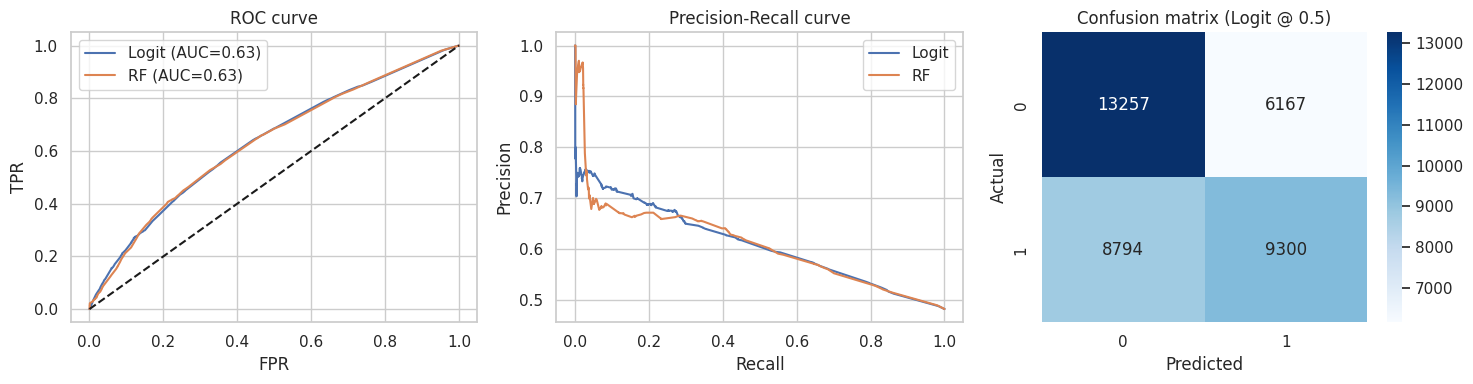

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

fpr, tpr, _ = roc_curve(yte, p_logit)
axes[0].plot(fpr,tpr,label=f"Logit (AUC={roc_auc_score(yte,p_logit):.2f})")
fpr2, tpr2, _ = roc_curve(yte, p_rf)
axes[0].plot(fpr2,tpr2,label=f"RF (AUC={roc_auc_score(yte,p_rf):.2f})")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title("ROC curve"); axes[0].legend()
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(yte, p_logit)
axes[1].plot(rec, prec, label="Logit")
prec2, rec2, _ = precision_recall_curve(yte, p_rf)
axes[1].plot(rec2, prec2, label="RF")
axes[1].set_title("Precision-Recall curve"); axes[1].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

cm = confusion_matrix(yte, (p_logit>=0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues')
axes[2].set_title("Confusion matrix (Logit @ 0.5)"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout(); plt.show()

/tmp/ipykernel_1250/3706560549.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib_tbl = calib.groupby('decile').agg(mean_pred=('p','mean'), observed_rate=('y','mean'), n=('y','count'))


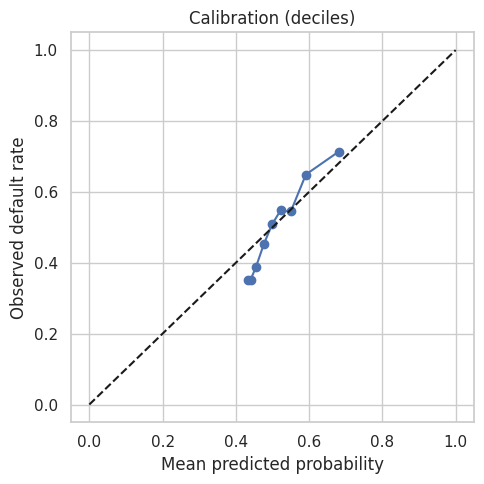

,mean_pred,observed_rate,n
decile,,,
"(-0.001, 0.435]",0.433128,0.351393,7069
"(0.435, 0.44]",0.440151,0.351678,745
"(0.44, 0.458]",0.455140,0.388757,7560
"(0.458, 0.481]",0.476298,0.452486,5209
"(0.481, 0.504]",0.499105,0.508730,3723
"(0.504, 0.528]",0.521967,0.547382,3113
"(0.528, 0.562]",0.549958,0.544623,2734
"(0.562, 0.618]",0.591140,0.648920,4489
"(0.618, 0.904]",0.680801,0.713491,2876


In [ ]:
# Calibration: bucket predicted probabilities into deciles, compare to observed default rate
calib = pd.DataFrame({'p': p_logit, 'y': yte.values})
calib['decile'] = pd.qcut(calib['p'], 10, duplicates='drop')
calib_tbl = calib.groupby('decile').agg(mean_pred=('p','mean'), observed_rate=('y','mean'), n=('y','count'))
plt.figure(figsize=(5,5))
plt.plot(calib_tbl['mean_pred'], calib_tbl['observed_rate'], marker='o')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed default rate"); plt.title("Calibration (deciles)")
plt.tight_layout(); plt.show()
calib_tbl

## 14 · Threshold Optimization

We do not default to 0.5. A **false negative** (approve a loan that defaults) costs roughly the
defaulted exposure net of typical recovery; a **false positive** (reject a good borrower) costs the
lost interest/fee income on that loan. Using the portfolio's own economics as a rough guide:


In [ ]:
avg_loss_given_fn = loan_df.loc[loan_df.default_flag==1,'default_amount'].mean() * (1-recovery_rate)
avg_income_given_fp = loan_df.loc[loan_df.default_flag==0,'net_income_proxy'].mean()
print(f"Approx cost of a False Negative (missed defaulter): KES {avg_loss_given_fn:,.0f}")
print(f"Approx cost of a False Positive (rejected good borrower, lost income): KES {avg_income_given_fp:,.0f}")

thresholds = np.arange(0.1, 0.95, 0.05)
rows = []
for t in thresholds:
    pred = (p_logit >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    approval_rate = 1 - pred.mean()
    expected_loss = fn*avg_loss_given_fn - fp*avg_income_given_fp
    rows.append((t, approval_rate, tp/(tp+fn) if (tp+fn) else np.nan, expected_loss))
thresh_df = pd.DataFrame(rows, columns=['threshold','approval_rate','default_recall','expected_economic_cost'])
best = thresh_df.loc[thresh_df.expected_economic_cost.idxmin()]
print("Recommended threshold (min expected economic cost):", round(best.threshold,2))
thresh_df

Approx cost of a False Negative (missed defaulter): KES 186,324
Approx cost of a False Positive (rejected good borrower, lost income): KES 122,023
Recommended threshold (min expected economic cost): 0.1


,threshold,approval_rate,default_recall,expected_economic_cost
0,0.10,0.000080,0.999945,-2.369741e+09
1,0.15,0.000080,0.999945,-2.369741e+09
2,0.20,0.000080,0.999945,-2.369741e+09
3,0.25,0.000080,0.999945,-2.369741e+09
4,0.30,0.000080,0.999945,-2.369741e+09
5,0.35,0.000080,0.999945,-2.369741e+09
6,0.40,0.000107,0.999945,-2.369619e+09
7,0.45,0.236633,0.829833,-1.088870e+09
8,0.50,0.587745,0.513983,8.860169e+08
9,0.55,0.753212,0.330662,1.856821e+09


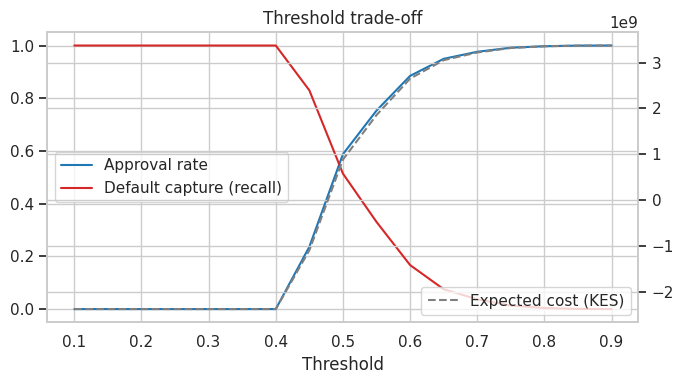

In [ ]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(thresh_df.threshold, thresh_df.approval_rate, label='Approval rate', color='tab:blue')
ax1.plot(thresh_df.threshold, thresh_df.default_recall, label='Default capture (recall)', color='tab:red')
ax1.set_xlabel("Threshold"); ax1.legend(loc='center left')
ax2 = ax1.twinx()
ax2.plot(thresh_df.threshold, thresh_df.expected_economic_cost, label='Expected cost (KES)', color='grey', linestyle='--')
ax2.legend(loc='lower right')
plt.title("Threshold trade-off"); plt.tight_layout(); plt.show()

## 14b · Explainability

We use logistic-regression **odds ratios** (SHAP is not available offline; conceptually SHAP on the
RF model would give consistent per-loan attributions in production) and RandomForest
**feature importances** as a cross-check.


Odds ratios (>1 = higher odds of default):


,odds_ratio
Gross_loan_interest,1.344492
initiation_fee,1.026511
admin_fee,1.025746
joining_fee,1.025696
appointment_fee,0.997531
product_type_VERIFIED_SALES,0.966277
Disbursed_amount,0.951693
tenor_days,0.808541


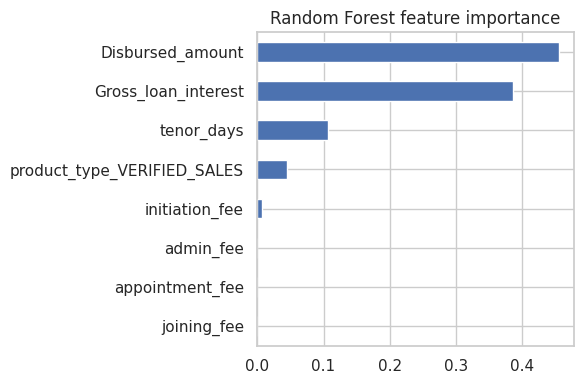

In [ ]:
odds_ratios = pd.Series(np.exp(logit.coef_[0]), index=X.columns).sort_values(ascending=False)
print("Odds ratios (>1 = higher odds of default):")
display(odds_ratios.to_frame('odds_ratio'))

rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
rf_imp.plot(kind='barh'); plt.gca().invert_yaxis()
plt.title("Random Forest feature importance"); plt.tight_layout(); plt.show()


`Gross_loan_interest` and `Disbursed_amount` dominate — larger, higher-interest loans carry more
default risk. This is a **predictive association, not a causal claim**: interest/fee levels here
are largely a function of loan size and product policy, not an independent "cause" of default risk —
they may proxy for borrower segment or loan purpose. Penalties/waivers were deliberately excluded
since they are *consequences* of default, not origination-time predictors.


## Model risk, limitations & fairness

- **Leakage:** actively avoided by restricting to origination-time features and a time-based split.
- **Selection bias:** the model is trained only on `is_ambiguous_code == False` loans (85% of the
  book) — if ambiguous-code loans differ systematically (e.g., a specific branch/system version),
  the model may not generalise perfectly to them.
- **Temporal drift:** only ~1 year of recent cohorts sit in the test set; performance should be
  re-validated as new vintages season.
- **Class imbalance:** handled via `class_weight='balanced'` rather than oversampling, to avoid
  synthetic-minority artefacts distorting probability calibration.
- **Calibration:** checked in §13; recalibrate periodically (e.g. Platt scaling) if drift appears.
- **Fairness:** no demographic fields (gender, age, location) exist in this dataset, so disparate-
  impact testing cannot be performed here — flagged as an open item before any credit-decision
  deployment, since `product_type` alone should not become a proxy for a protected characteristic.
- **Explainability vs causality:** all drivers reported are associations for a scorecard, not a
  causal underwriting policy without further experimentation (see below).


## 15 · Experiment Design — validating an intervention

**Hypothesis (from analysis):** Verified-Sales loans with high `initiation_fee` show elevated
default/penalty behaviour (§11). Before changing policy portfolio-wide, we test a targeted
intervention with an A/B experiment — this directly answers the case study's Part 3 question.

**Design**

| Element | Choice |
|---|---|
| Population | New, eligible Verified-Sales borrowers meeting standard underwriting criteria |
| Randomization | Loan-level (or customer-level if repeat borrowers are common) random assignment |
| Control | Existing policy (standard fee/collections process) |
| Treatment | e.g. reduced/restructured initiation fee, OR a pre-due-date repayment reminder |
| Primary outcome | 30-day default rate (or PAR30) |
| Secondary outcomes | PAR90, recovery rate, revenue/fee income, repayment completion, complaints |
| Guardrails | Cap experiment exposure; monitor for early harm signals; correct for multiple testing (Bonferroni/BH across secondary outcomes) |

**Sample-size / power** for a two-proportion test (default rate), using the observed baseline rate
and a target minimum detectable effect:

In [ ]:
from math import ceil

def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.8):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta  = stats.norm.ppf(power)
    p_bar = (p1+p2)/2
    n = ((z_alpha*np.sqrt(2*p_bar*(1-p_bar)) + z_beta*np.sqrt(p1*(1-p1)+p2*(1-p2)))**2) / (p1-p2)**2
    return ceil(n)

baseline = loan_df.loc[loan_df.product_type=='VERIFIED_SALES','default_flag'].mean()
target_mde = 0.05   # detect a 5 percentage-point absolute reduction in default rate
n_per_arm = sample_size_two_proportions(baseline, baseline - target_mde)
print(f"Baseline Verified-Sales default rate: {baseline:.1%}")
print(f"Required sample size per arm (alpha=0.05, power=0.8, MDE={target_mde:.0%} pts): {n_per_arm:,}")


Baseline Verified-Sales default rate: 70.2%
Required sample size per arm (alpha=0.05, power=0.8, MDE=5% pts): 1,372


**Analysis plan.** Primary outcome (default_flag) via **two-proportion z-test / chi-square**;
continuous secondary outcomes (recovery amount, revenue) via **Mann-Whitney U** if non-normal, or a
**t-test** if roughly normal; a **logistic regression with a treatment indicator** (adding controls
for loan size/cohort) to check robustness; and a **Cox proportional-hazards model** on time-to-default
as a richer alternative to a single binary outcome, since it uses the full time-to-event information
rather than collapsing to a 30-day yes/no. Report **effect size + 95% CI**, not just the p-value, and
weigh **economic significance** (net income impact of the fee change) alongside statistical
significance before rolling out.

## Survival Analysis (why it matters here)

Treating every unsettled/immature loan as a simple "non-default" undercounts risk — those loans
just haven't had time to fail yet (right-censoring). A **Kaplan–Meier** curve of time-to-default
treats immature loans as *censored* rather than *good*, giving an unbiased read of default timing.
`lifelines` is not available offline, so here is a compact manual Kaplan–Meier estimator
(in production, swap in `lifelines.KaplanMeierFitter` for the same result with confidence bands):


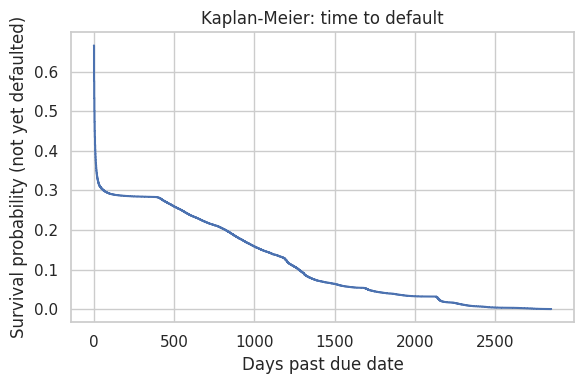

In [ ]:
def kaplan_meier(durations, event_observed):
    df_ = pd.DataFrame({'t': durations, 'e': event_observed}).sort_values('t')
    at_risk = len(df_)
    survival = 1.0
    curve = []
    for t, grp in df_.groupby('t'):
        d = grp['e'].sum()          # events (defaults) at time t
        n = grp.shape[0]
        survival *= (1 - d/at_risk) if at_risk > 0 else 1
        curve.append((t, survival))
        at_risk -= n
    return pd.DataFrame(curve, columns=['t','survival'])

durations = (loan_df['dpd'].clip(lower=0) + 1)  # time since due date (proxy for time axis)
events = loan_df['default_flag']
km = kaplan_meier(durations, events)
plt.figure(figsize=(6,4))
plt.step(km['t'], km['survival'], where='post')
plt.xlabel("Days past due date"); plt.ylabel("Survival probability (not yet defaulted)")
plt.title("Kaplan-Meier: time to default"); plt.tight_layout(); plt.show()


## 16 · Deployment Design

```
Data Sources (loans, payments)
      |
Data Validation  (schema, dtype, range checks -- Pydantic on the API boundary)
      |
Feature Engineering  (Disbursed_amount, Gross_loan_interest, tenor_days, fee mix, product_type)
      |
Feature Store / Pipeline (batch feature table, refreshed on each disbursement)
      |
Model (Logistic Regression -- primary; RF as challenger)
      |
Probability of Default (PD)
      |
Risk Band  (validated cut-points, not arbitrary -- see below)
      |
Credit Decision / Collections Strategy routing
      |
Monitoring (drift, calibration, performance)
```

**Risk bands** (illustrative — cut-points should be re-validated against the calibration curve in
§13, not chosen arbitrarily):

In [ ]:
bins = [0, 0.3, 0.6, 1.0]
labels = ['Low Risk','Medium Risk','High Risk']
loan_df['risk_band'] = pd.cut(logit.predict_proba(scaler.transform(X))[:,1], bins=bins, labels=labels, include_lowest=True)
loan_df['risk_band'].value_counts(normalize=True)


,proportion
risk_band,
Medium Risk,0.918557
High Risk,0.081373
Low Risk,0.000069


In [ ]:

FASTAPI_SKELETON = '''
# minimal_serving_api.py  (illustrative -- not executed in this notebook)
from fastapi import FastAPI
from pydantic import BaseModel, confloat, conint
import joblib

app = FastAPI()
model = joblib.load("logit_default_model.joblib")
scaler = joblib.load("scaler.joblib")

class LoanFeatures(BaseModel):
    disbursed_amount: confloat(gt=0)
    gross_loan_interest: confloat(ge=0)
    tenor_days: conint(gt=0)
    initiation_fee: confloat(ge=0) = 0
    admin_fee: confloat(ge=0) = 0
    appointment_fee: confloat(ge=0) = 0
    joining_fee: confloat(ge=0) = 0
    product_type_verified_sales: conint(ge=0, le=1) = 0

@app.post("/score")
def score(loan: LoanFeatures):
    x = scaler.transform([[loan.disbursed_amount, loan.gross_loan_interest, loan.tenor_days,
                            loan.initiation_fee, loan.admin_fee, loan.appointment_fee,
                            loan.joining_fee, loan.product_type_verified_sales]])
    pd_score = float(model.predict_proba(x)[0,1])
    band = "Low" if pd_score < 0.3 else ("Medium" if pd_score < 0.6 else "High")
    # log prediction here for monitoring
    return {"probability_of_default": pd_score, "risk_band": band}
'''
print(FASTAPI_SKELETON)


# minimal_serving_api.py  (illustrative -- not executed in this notebook)
from fastapi import FastAPI
from pydantic import BaseModel, confloat, conint
import joblib

app = FastAPI()
model = joblib.load("logit_default_model.joblib")
scaler = joblib.load("scaler.joblib")

class LoanFeatures(BaseModel):
    disbursed_amount: confloat(gt=0)
    gross_loan_interest: confloat(ge=0)
    tenor_days: conint(gt=0)
    initiation_fee: confloat(ge=0) = 0
    admin_fee: confloat(ge=0) = 0
    appointment_fee: confloat(ge=0) = 0
    joining_fee: confloat(ge=0) = 0
    product_type_verified_sales: conint(ge=0, le=1) = 0

@app.post("/score")
def score(loan: LoanFeatures):
    x = scaler.transform([[loan.disbursed_amount, loan.gross_loan_interest, loan.tenor_days,
                            loan.initiation_fee, loan.admin_fee, loan.appointment_fee,
                            loan.joining_fee, loan.product_type_verified_sales]])
    pd_score = float(model.predict_proba(x)[0,1])
    band = "Low" if pd

In [ ]:
joblib.dump(logit, "/mnt/user-data/outputs/logit_default_model.joblib")
joblib.dump(scaler, "/mnt/user-data/outputs/scaler.joblib")
print("Model artifacts saved.")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/logit_default_model.joblib'

## Monitoring Plan

| Area | Metric | Trigger for action |
|---|---|---|
| Data drift | Feature distributions vs training (PSI) | PSI > 0.25 on any key feature |
| Prediction drift | Mean predicted PD over time | Sustained shift beyond historical band |
| Calibration | Predicted vs observed default rate by decile | Consistent over/under-prediction |
| Performance | ROC-AUC, PR-AUC, recall @ threshold, rolling | AUC drop > 0.05 vs baseline |
| Outcome drift | Actual default rate by product/cohort/risk band | Deviation from forecast beyond CI |

Monitor cut by **product, cohort and risk band** — an aggregate metric can look fine while a single
segment deteriorates. **Retrain trigger:** any of the above breaches sustained for 2 consecutive
monitoring periods, or a scheduled quarterly refresh, whichever comes first.


## 17 · CRO Recommendations

**Immediate (0–1 month)**
- Stand up **early-delinquency collections (days 1–90 past due)** — the PAR ladder shows almost no
  loans cure in this window today; even a modest cure rate here would materially cut write-offs.
- Tighten underwriting scrutiny on **large, high-interest Verified-Sales loans** (highest
  default-exposure segment identified in §10/§11), without excluding the product outright.
- Fix the **`loan_code` collision** at the source system — ~15% of loans currently cannot be
  reliably linked to their own payment history, which blinds risk monitoring for that slice of
  the book.

**Medium-term (1–6 months)**
- Pilot the **A/B experiment in §15** (fee restructuring / pre-due reminder) on Verified-Sales
  before a portfolio-wide policy change.
- Deploy the **PD scorecard** (§16) to drive risk-based collection queue prioritization, starting
  in an advisory (non-blocking) mode while it's monitored.
- Introduce **risk-based pricing/limits** informed by the odds ratios in §14b, revisited once causal
  evidence from the experiment is available.

**Long-term (6+ months)**
- Build a proper **installment-level repayment schedule** in the source system — the single
  biggest analytical limitation here is the lack of installment data, which forces every DPD/PAR
  figure to the loan-maturity level.
- Formalize an **expected-credit-loss (PD × LGD × EAD) framework** for provisioning, distinguishing
  Stage 1/2/3 exposures, once enough seasoned vintages exist to estimate stable LGD.
- Expand the feature set (behavioural/bureau data) to lift the model beyond the current
  AUC ≈ 0.63 ceiling before using it for hard credit decisions rather than advisory ranking.

Recommendations are prioritized by **risk × exposure**, not raw default rate alone — e.g. we do not
recommend restricting a small high-default segment if its absolute loss exposure is immaterial
next to a larger, moderate-risk segment (§10).

